<a href="https://colab.research.google.com/github/ZALER-01/AngularPractice/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simple Linear Regression y = b₀ + b₁ X₁

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv(r'/content/Salary_Data.csv')
print(df)

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [12]:
import requests
import pandas as pd
from datetime import datetime

# =========================
# HEADERS (IMPORTANT for NSE)
# =========================
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
}

session = requests.Session()

# =========================
# GET NSE PRICE
# =========================
def get_nse_price(symbol):
    try:
        url = f"https://www.nseindia.com/api/quote-equity?symbol={symbol}"

        # First call to set cookies
        session.get("https://www.nseindia.com", headers=headers)

        response = session.get(url, headers=headers)
        data = response.json()

        price = data["priceInfo"]["lastPrice"]
        return price

    except Exception as e:
        print(f"Error fetching {symbol}: {e}")
        return None

# =========================
# SIMPLE SIGNAL (DEMO)
# =========================
def simple_signal(price):
    if price > 2500:
        return "UPTREND"
    else:
        return "DOWNTREND"

# =========================
# MAIN
# =========================
def run_portfolio():
    portfolio = ["RELIANCE", "HDFCBANK", "TCS"]

    results = []

    for stock in portfolio:
        print(f"Processing {stock}...")

        price = get_nse_price(stock)

        if price is None:
            continue

        signal = simple_signal(price)

        results.append({
            "Stock": stock,
            "Price": price,
            "Signal": signal,
            "Date": datetime.now().strftime("%Y-%m-%d")
        })

    df = pd.DataFrame(results)

    if df.empty:
        print("❌ No data fetched")
        return df

    return df

# =========================
# RUN
# =========================
df = run_portfolio()

print("\n📊 Output:")
print(df)

# Save
if not df.empty:
    df.to_csv(f"nse_signals_{datetime.now().strftime('%Y%m%d')}.csv", index=False)

Processing RELIANCE...
Processing HDFCBANK...
Processing TCS...

📊 Output:
      Stock    Price     Signal        Date
0  RELIANCE  1423.80  DOWNTREND  2026-03-25
1  HDFCBANK   791.85  DOWNTREND  2026-03-25
2       TCS  2412.90  DOWNTREND  2026-03-25


In [20]:
import os
os.environ["YFINANCE_USE_CURL"] = "False"

import yfinance as yf
import pandas as pd
from datetime import datetime

# =========================
# 📊 RSI FUNCTION
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# 📊 ADD INDICATORS
# =========================
def add_indicators(data):
    data['SMA50'] = data['Close'].rolling(50).mean()
    data['SMA200'] = data['Close'].rolling(200).mean()
    data['RSI'] = calculate_rsi(data)
    return data

# =========================
# 🎯 SIGNAL LOGIC
# =========================
def generate_signal(prev, curr):

    prev_sma50 = prev['SMA50'].item()
    prev_sma200 = prev['SMA200'].item()
    curr_sma50 = curr['SMA50'].item()
    curr_sma200 = curr['SMA200'].item()
    rsi = curr['RSI'].item()
    price = curr['Close'].item()

    # 🟢 STRONG BUY
    if prev_sma50 < prev_sma200 and curr_sma50 > curr_sma200 and rsi < 70:
        return "🟢 STRONG BUY"

    # 🔴 STRONG SELL
    elif prev_sma50 > prev_sma200 and curr_sma50 < curr_sma200 and rsi > 30:
        return "🔴 STRONG SELL"

    # 🟢 BUY (Oversold bounce)
    elif rsi < 30 and price > curr_sma50:
        return "🟢 BUY (Oversold Bounce)"

    # 🔴 SELL (Overbought)
    elif rsi > 70:
        return "🔴 SELL (Overbought)"

    # 🟡 HOLD (Uptrend but no fresh entry)
    elif curr_sma50 > curr_sma200:
        return "🟡 HOLD (Uptrend)"

    # 🟡 HOLD (Downtrend)
    else:
        return "🟡 HOLD (Downtrend)"

# =========================
# 🚀 MAIN FUNCTION
# =========================
def analyze_stocks(tickers):
    results = []

    for ticker in tickers:
        print(f"Processing {ticker}...")

        try:
            data = yf.download(
                ticker,
                period="1y",
                interval="1d",
                progress=False,
                auto_adjust=True
            )

            if data is None or data.empty:
                print("No data")
                continue

        except Exception as e:
            print(f"Error: {e}")
            continue

        data = add_indicators(data)
        data = data.dropna()

        if len(data) < 2:
            continue

        latest = data.iloc[-1]
        previous = data.iloc[-2]

        signal = generate_signal(previous, latest)

        results.append({
            "Ticker": ticker,
            "Signal": signal,
            "Price": round(latest['Close'].item(), 2),
            "SMA50": round(latest['SMA50'].item(), 2),
            "SMA200": round(latest['SMA200'].item(), 2),
            "RSI": round(latest['RSI'].item(), 2),
            "Trend": "Bullish" if latest['SMA50'].item() > latest['SMA200'].item() else "Bearish",
            "Date": latest.name.strftime("%Y-%m-%d")
        })

    df = pd.DataFrame(results)

    if df.empty:
        print("❌ No data fetched")
        return df

    return df.sort_values(by="Signal")

# =========================
# ▶️ RUN
# =========================
if __name__ == "__main__":

    portfolio = [
        "RELIANCE.NS",
        "HDFCBANK.NS",
        "TCS.NS",
        "NIFTYBEES.NS"
    ]

    df = analyze_stocks(portfolio)

    print("\n📊 FINAL OUTPUT:")
    print(df)

    if not df.empty:
        filename = f"sma_rsi_signals_{datetime.now().strftime('%Y%m%d')}.csv"
        df.to_csv(filename, index=False)
        print(f"\n✅ Saved: {filename}")

Processing RELIANCE.NS...
Processing HDFCBANK.NS...
Processing TCS.NS...
Processing NIFTYBEES.NS...

📊 FINAL OUTPUT:
         Ticker              Signal    Price    SMA50   SMA200    RSI  \
0   RELIANCE.NS  🟡 HOLD (Downtrend)  1424.20  1415.03  1447.26  59.40   
1   HDFCBANK.NS  🟡 HOLD (Downtrend)   791.65   891.92   960.89  33.14   
2        TCS.NS  🟡 HOLD (Downtrend)  2414.40  2783.12  3018.74  29.08   
3  NIFTYBEES.NS  🟡 HOLD (Downtrend)   265.34   282.29   285.23  36.08   

     Trend        Date  
0  Bearish  2026-03-25  
1  Bearish  2026-03-25  
2  Bearish  2026-03-25  
3  Bearish  2026-03-25  

✅ Saved: sma_rsi_signals_20260325.csv


In [23]:
import os
os.environ["YFINANCE_USE_CURL"] = "False"

import yfinance as yf
import pandas as pd

# =========================
# 📊 RSI FUNCTION
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# 📊 SUPPORT LEVEL
# =========================
def get_support_level(data):
    return round(data['Low'].tail(20).min(), 2)

# =========================
# 🎯 SIGNAL LOGIC
# =========================
def generate_signal(curr):
    sma50 = curr['SMA50'].item()
    sma200 = curr['SMA200'].item()
    rsi = curr['RSI'].item()

    if sma50 > sma200 and rsi < 70:
        return "🟢 BUY"
    elif sma50 < sma200 and rsi > 40:
        return "🔴 SELL"
    else:
        return "🟡 HOLD"

# =========================
# 🚀 MAIN FUNCTION
# =========================
def analyze_stock():

    # 🔹 USER INPUT
    stock = input("Enter Stock (e.g. RELIANCE.NS): ").upper()
    buy_price = float(input("Enter Your Buying Price: "))
    buy_date = input("Enter Buying Date (YYYY-MM-DD): ")

    print(f"\nFetching data for {stock}...")

    # =========================
    # 📥 FETCH STOCK DATA
    # =========================
    try:
        data = yf.download(
            stock,
            period="1y",
            interval="1d",
            progress=False,
            auto_adjust=True
        )

        if data is None or data.empty:
            print(f"❌ No data found for {stock}")
            print("👉 Example: HDFCBANK.NS instead of HDFC.NS")
            return

    except Exception as e:
        print(f"Error fetching stock: {e}")
        return

    # =========================
    # 📥 FETCH NIFTY DATA
    # =========================
    try:
        nifty = yf.download(
            "^NSEI",
            period="1y",
            interval="1d",
            progress=False,
            auto_adjust=True
        )

        if nifty is None or nifty.empty:
            print("⚠️ Could not fetch market data")
            market_return = None
        else:
            # Find nearest valid date
            nifty_start = nifty[nifty.index >= buy_date].iloc[0]['Close'].item()
            nifty_now = nifty.iloc[-1]['Close'].item()
            market_return = ((nifty_now - nifty_start) / nifty_start) * 100

    except:
        market_return = None

    # =========================
    # 📊 CALCULATE INDICATORS
    # =========================
    data['SMA50'] = data['Close'].rolling(50).mean()
    data['SMA200'] = data['Close'].rolling(200).mean()
    data['RSI'] = calculate_rsi(data)

    data = data.dropna()

    if len(data) < 1:
        print("❌ Not enough data")
        return

    latest = data.iloc[-1]

    # =========================
    # 📈 RETURNS
    # =========================
    current_price = latest['Close'].item()
    stock_return = ((current_price - buy_price) / buy_price) * 100

    # =========================
    # 📊 SUPPORT
    # =========================
    support = get_support_level(data)

    # =========================
    # 🎯 SIGNAL
    # =========================
    signal = generate_signal(latest)

    # =========================
    # 📊 OUTPUT
    # =========================
    print("\n📊 ANALYSIS RESULT")
    print("="*40)
    print(f"Stock: {stock}")
    print(f"Current Price: {round(current_price,2)}")
    print(f"Your Return: {round(stock_return,2)}%")

    if market_return is not None:
        print(f"Market Return (NIFTY): {round(market_return,2)}%")
    else:
        print("Market Return: Not available")

    print(f"RSI: {round(latest['RSI'].item(),2)}")
    print(f"SMA50: {round(latest['SMA50'].item(),2)}")
    print(f"SMA200: {round(latest['SMA200'].item(),2)}")
    print(f"Support Level: {support}")
    print(f"Signal: {signal}")

    # =========================
    # 💡 SUGGESTION
    # =========================
    print("\n💡 SUGGESTION:")

    if signal == "🟢 BUY":
        print("Strong stock. You can consider buying more.")
    elif signal == "🔴 SELL":
        print("Weak trend. Consider reducing or exiting.")
    else:
        print("Hold and wait for better opportunity.")

# =========================
# ▶️ RUN
# =========================
if __name__ == "__main__":
    analyze_stock()

Enter Stock (e.g. RELIANCE.NS): HDFCBANK.NS
Enter Your Buying Price: 750
Enter Buying Date (YYYY-MM-DD): 2026-04-24

Fetching data for HDFCBANK.NS...

📊 ANALYSIS RESULT
Stock: HDFCBANK.NS
Current Price: 792.35
Your Return: 5.65%
Market Return: Not available
RSI: 33.32
SMA50: 891.94
SMA200: 960.9
Support Level: Ticker
HDFCBANK.NS    741.05
dtype: float64
Signal: 🟡 HOLD

💡 SUGGESTION:
Hold and wait for better opportunity.


In [19]:
import smtplib
from email.mime.text import MIMEText

def send_email_alert(df):
    sender = "your_email@gmail.com"
    receiver = "your_email@gmail.com"
    password = "your_app_password"  # 👈 Use App Password

    # Filter only important signals
    alerts = df[df['Signal'].str.contains("BUY|SELL")]

    if alerts.empty:
        print("No alerts to send.")
        return

    message = alerts.to_string(index=False)

    msg = MIMEText(message)
    msg['Subject'] = "🚨 Stock Signal Alert"
    msg['From'] = sender
    msg['To'] = receiver

    try:
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
            server.login(sender, password)
            server.send_message(msg)
        print("📧 Email sent successfully!")
    except Exception as e:
        print("Email failed:", e)

In [24]:
import os
os.environ["YFINANCE_USE_CURL"] = "False"

import yfinance as yf
import pandas as pd

# =========================
# 📊 RSI FUNCTION
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = -delta.clip(upper=0).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# 📊 SUPPORT LEVEL
# =========================
def get_support_level(data):
    return float(data['Low'].tail(20).min())

# =========================
# 🎯 TARGET & STOPLOSS
# =========================
def calculate_target_stoploss(price, support):
    stop_loss = support * 0.98
    risk = price - support
    target = price + (2 * risk)
    return round(target, 2), round(stop_loss, 2)

# =========================
# 🎯 SIGNAL LOGIC
# =========================
def generate_signal(curr):
    sma50 = curr['SMA50'].item()
    sma200 = curr['SMA200'].item()
    rsi = curr['RSI'].item()

    if sma50 > sma200 and rsi < 70:
        return "🟢 BUY"
    elif sma50 < sma200 and rsi > 40:
        return "🔴 SELL"
    else:
        return "🟡 HOLD"

# =========================
# 📊 FETCH DATA
# =========================
def fetch_data(ticker):
    try:
        data = yf.download(
            ticker,
            period="1y",
            interval="1d",
            progress=False,
            auto_adjust=True
        )
        if data is None or data.empty:
            return None
        return data
    except:
        return None

# =========================
# 📊 MARKET RETURN
# =========================
def calculate_market_return(nifty, buy_date):
    try:
        start_price = nifty[nifty.index >= buy_date].iloc[0]['Close'].item()
        current_price = nifty.iloc[-1]['Close'].item()
        return ((current_price - start_price) / start_price) * 100
    except:
        return None

# =========================
# 🚀 MAIN ANALYSIS
# =========================
def analyze_stock():

    # 🔹 USER INPUT
    stock = input("Enter Stock (e.g. RELIANCE.NS): ").upper()
    buy_price = float(input("Enter Your Buying Price: "))
    buy_date = input("Enter Buying Date (YYYY-MM-DD): ")

    print(f"\nFetching data for {stock}...")

    # 📥 STOCK DATA
    data = fetch_data(stock)

    if data is None:
        print(f"❌ No data found for {stock}")
        print("👉 Example: HDFCBANK.NS instead of HDFC.NS")
        return

    # 📥 MARKET DATA
    nifty = fetch_data("^NSEI")

    # 📊 INDICATORS
    data['SMA50'] = data['Close'].rolling(50).mean()
    data['SMA200'] = data['Close'].rolling(200).mean()
    data['RSI'] = calculate_rsi(data)

    data = data.dropna()

    if len(data) == 0:
        print("❌ Not enough data")
        return

    latest = data.iloc[-1]

    # 📈 RETURNS
    current_price = latest['Close'].item()
    stock_return = ((current_price - buy_price) / buy_price) * 100

    # 📈 MARKET RETURN
    if nifty is not None:
        market_return = calculate_market_return(nifty, buy_date)
    else:
        market_return = None

    # 📊 SUPPORT
    support = get_support_level(data)

    # 🎯 TARGET & STOPLOSS
    target, stop_loss = calculate_target_stoploss(current_price, support)

    # 🎯 SIGNAL
    signal = generate_signal(latest)

    # =========================
    # 📊 OUTPUT
    # =========================
    print("\n📊 ANALYSIS RESULT")
    print("=" * 40)
    print(f"Stock: {stock}")
    print(f"Current Price: {round(current_price, 2)}")
    print(f"Your Return: {round(stock_return, 2)}%")

    if market_return is not None:
        print(f"Market Return (NIFTY): {round(market_return, 2)}%")
    else:
        print("Market Return: Not available")

    print(f"RSI: {round(latest['RSI'].item(), 2)}")
    print(f"SMA50: {round(latest['SMA50'].item(), 2)}")
    print(f"SMA200: {round(latest['SMA200'].item(), 2)}")
    print(f"Support Level: {support}")
    print(f"Target Price: {target}")
    print(f"Stop Loss: {stop_loss}")
    print(f"Signal: {signal}")

    # =========================
    # 💡 SUGGESTION
    # =========================
    print("\n💡 SUGGESTION:")

    if signal == "🟢 BUY":
        print(f"Strong stock. Target: {target}, Stop Loss: {stop_loss}")

    elif signal == "🔴 SELL":
        print("Weak trend. Consider exiting or reducing position.")

    else:
        if latest['RSI'].item() < 35:
            print(f"Oversold zone. Possible bounce.\nTarget: {target}, Stop Loss: {stop_loss}")
        else:
            print("Hold and wait for better opportunity.")

# =========================
# ▶️ RUN
# =========================
if __name__ == "__main__":
    analyze_stock()

Enter Stock (e.g. RELIANCE.NS): HDFCBANK.NS
Enter Your Buying Price: 750
Enter Buying Date (YYYY-MM-DD): 2026-03024

Fetching data for HDFCBANK.NS...

📊 ANALYSIS RESULT
Stock: HDFCBANK.NS
Current Price: 792.6
Your Return: 5.68%
Market Return: Not available
RSI: 33.39
SMA50: 891.94
SMA200: 960.9
Support Level: 741.0499877929688
Target Price: 895.7
Stop Loss: 726.23
Signal: 🟡 HOLD

💡 SUGGESTION:
Oversold zone. Possible bounce.
Target: 895.7, Stop Loss: 726.23


/tmp/ipykernel_238/864779450.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(data['Low'].tail(20).min())


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
x = df.iloc[:,:-1].values
y = df.iloc[:,1].values
print(x)
print(y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 0)

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)


LinearRegression()

**Predicting The test set results**

In [ ]:
y_pred = regressor.predict(x_test)

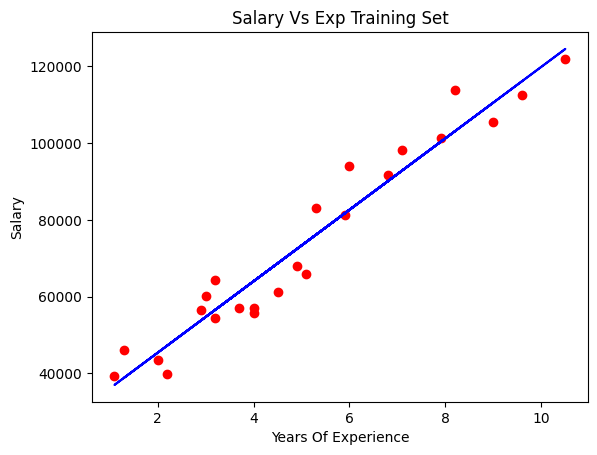

In [ ]:
plt.scatter(x_train , y_train , color = 'red')
plt.plot(x_train, regressor.predict(x_train), color='blue')
plt.title("Salary Vs Exp Training Set")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.show()

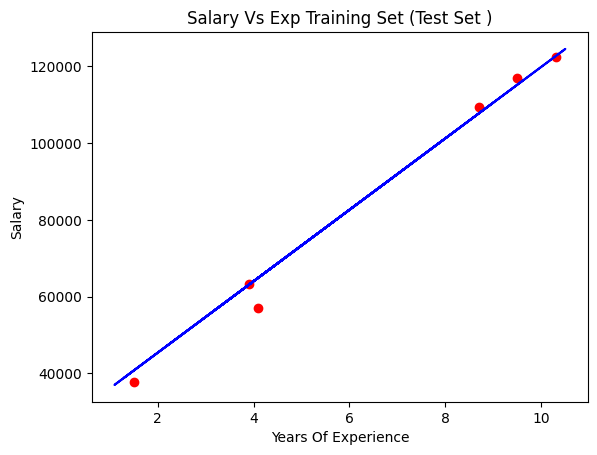

In [ ]:
plt.scatter(x_test , y_test , color = 'red')
plt.plot(x_train, regressor.predict(x_train), color='blue')
plt.title("Salary Vs Exp Training Set (Test Set )")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.show()

In [ ]:
https://www.superdatascience.com/pages/ml-regression-bonus-1

SyntaxError: invalid syntax (1586134094.py, line 1)